In [1]:
# import necesary lib's ...

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset 

In [2]:
FILEPATH = "../data/raw/Alzheimer_DataSet.csv"
df = pd.read_csv(FILEPATH)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Columns: 353 entries, Test_data to Volume (WM Parcellation) of FourthVentricle
dtypes: float64(345), int64(3), object(5)
memory usage: 4.7+ MB


In [3]:
df.memory_usage()

Index                                                             128
RID                                                             13896
Test_data                                                       13896
Diagnosis                                                       13896
FDG_PET                                                         13896
                                                                ...  
Volume (Cortical Parcellation) of RightMiddleTemporal           13896
Surface Area of RightMiddleTemporal                             13896
Cortical Thickness Average of RightMiddleTemporal               13896
Cortical Thickness Standard Deviation of RightMiddleTemporal    13896
Volume (WM Parcellation) of FourthVentricle                     13896
Length: 372, dtype: int64

In [4]:
rows, cols = df.shape

print("Total no. of rows: ", rows)
print("Total no. of cols: ", cols)

Total no. of rows:  1737
Total no. of cols:  371


### First let's try to preprocess numerical and categorical cols separately.

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

In [6]:
categorical_cols.shape, numeric_cols.shape

((1737, 5), (1737, 366))

From the above results we can clearly see that there are only `5` *categorical* columns and rest all are *numeric* columns.

In [8]:
categorical_cols.head(5)

,Diagnosis,Gender,Ethnicity,Race,Marital_status
0,CN,Male,Not Hisp/Latino,White,Married
1,AD,Male,Not Hisp/Latino,Am Indian/Alaskan,Married
2,LMCI,Male,Not Hisp/Latino,Black,Married
3,CN,Male,Not Hisp/Latino,White,Married
4,LMCI,Female,Not Hisp/Latino,White,Married


In [26]:
numerical_column_name = list(df.columns)
with open('../reports/numeric_column_names.txt', mode='w', encoding='utf-8') as file:
    file.write(",".join(numerical_column_name))

After running the above code segment, we find out that there are so many features. It is very difficult to work will all, since we need to perform the preprocessing for ML therefore we move towards to Feature Scaling part.
<br/>
Before that let's just do some `null` and remove those columns which are totally empty or try to fill them if possible.

In [21]:
columns_to_remove = []
total_rows = df.shape[0]
threshold = 0.5

for col in df.columns:
    count = df[col].isnull().sum()
    percentage_val = (count/total_rows)*100
    if count > 0:
        print(f"{col} contains {count} null values.\tApprox {percentage_val:.2f}%")

        if percentage_val >= threshold:
            columns_to_remove.append(col)

Volume (WM Parcellation) of RightUndetermined contains 1737 null values.	Approx 100.00%
Volume (WM Parcellation) of RightWMHypoIntensities contains 1737 null values.	Approx 100.00%
Volume (Cortical Parcellation) of LeftCorpusCallosum contains 1737 null values.	Approx 100.00%
Surface Area of LeftCorpusCallosum contains 1737 null values.	Approx 100.00%
Cortical Thickness Average of LeftCorpusCallosum contains 1737 null values.	Approx 100.00%
Cortical Thickness Standard Deviation of LeftCorpusCallosum contains 1737 null values.	Approx 100.00%
Volume (Cortical Parcellation) of LeftHemisphereWM contains 1737 null values.	Approx 100.00%
Volume (WM Parcellation) of LeftInterior contains 1737 null values.	Approx 100.00%
Volume (WM Parcellation) of LeftNonWMHypoIntensities contains 1737 null values.	Approx 100.00%
Volume (WM Parcellation) of LeftUndetermined contains 1737 null values.	Approx 100.00%
Volume (WM Parcellation) of LeftWMHypoIntensities contains 1737 null values.	Approx 100.00%
Volu

As we can see from the above results, there are some columns are totally empty, it's better if we remove them before going any further.

In [22]:
df.drop(columns=columns_to_remove, inplace=True)

In [27]:
df.drop(columns=['RID'], inplace=True)

In [23]:
rows, cols = df.shape

print("AFTER REMOVING")
print("Total no. of rows: ", rows)
print("Total no. of cols: ", cols)

AFTER REMOVING
Total no. of rows:  1737
Total no. of cols:  354


### Feature Selection using Lasso

In [38]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

### Filter out training and target features

In [36]:
X, y = df.drop(columns=['Diagnosis']), df['Diagnosis']
X.shape, y.shape

((1737, 352), (1737,))

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=23,
                                                   stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1215, 352), (522, 352), (1215,), (522,))

In [55]:
categorical_columns = list(X_train.select_dtypes(include=['object']).columns)
categorical_columns

['Gender', 'Ethnicity', 'Race', 'Marital_status']

In [58]:
ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), categorical_columns),
    ],
    remainder='passthrough'
)

In [59]:
X_train_encoded = ct.fit_transform(X_train)

In [60]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

In [62]:
print(X_train_encoded.shape, y_train_encoded.shape)
print(type(X_train_encoded), type(y_train_encoded))

(1215, 359) (1215,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [73]:
r2_scores = []
coefficients = []

X_test_encoded = ct.transform(X_test)
y_test_encoded = label_encoder.transform(y_test)

different_alpha_values = [0.5, 0.25, 0.0001, 1, 5, 10] 

for alpha in different_alpha_values:
    lasso_regression = Lasso(alpha=alpha, max_iter=10000, tol=0.01)

    lasso_regression.fit(X_train_encoded, y_train_encoded)
    predictions = lasso_regression.predict(X_test_encoded)

    score = r2_score(y_test_encoded, predictions)
    r2_scores.append(score)
    coefficients.append(list(lasso_regression.coef_))

print(f"Best R2 Score: {max(r2_scores)}")

C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.578e+02, tolerance: 1.894e+01
  model = cd_fast.enet_coordinate_descent(
C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.138e+02, tolerance: 1.894e+01
  model = cd_fast.enet_coordinate_descent(
C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

Best R2 Score: 0.08150772121573846


C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.412e+01, tolerance: 1.894e+01
  model = cd_fast.enet_coordinate_descent(


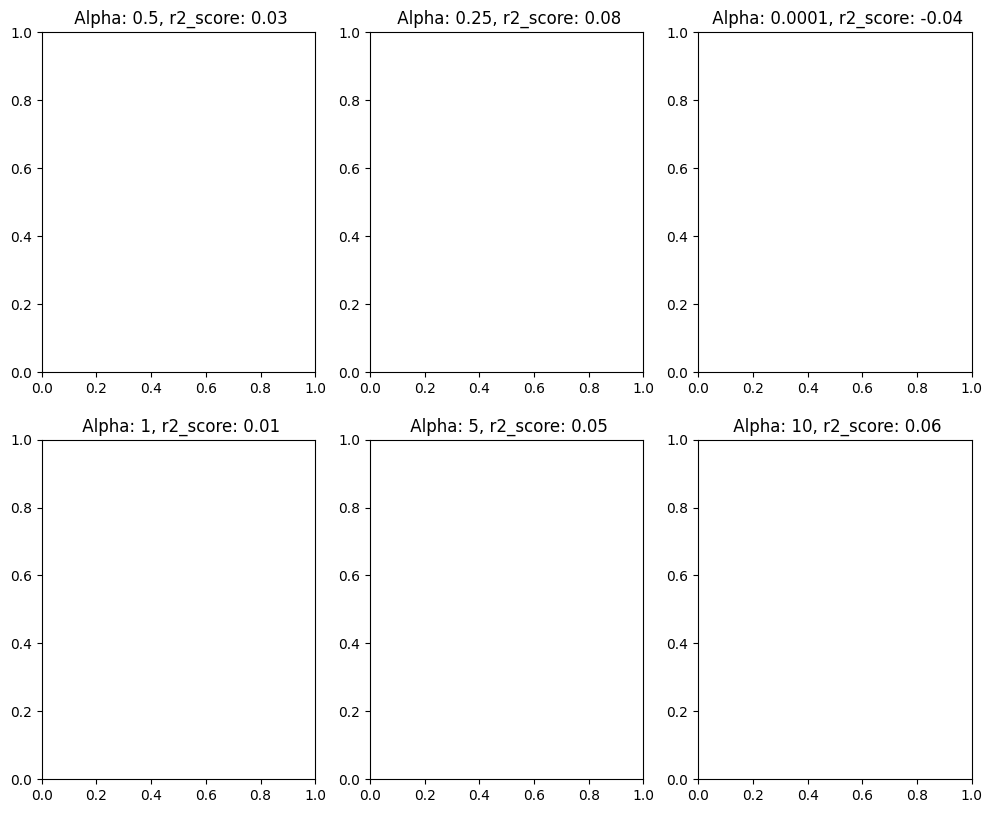

In [74]:
plt.figure(figsize=(12, 15))
for idx in range(len(coefficients)):
    plt.subplot(idx + 331)
    plt.title(f" Alpha: {different_alpha_values[idx]}, r2_score: {r2_scores[idx]:.2f}")
plt.show()